# L1 · Notebook 01 — GridWorld 基础：MDP 五元组、轨迹、回报

**对应 PPT**：`L1-basic.tex` §MDP 定义 / 5×5 网格示例

**对应教材**：`miclDRL/chapters/part2-ch01-basic-concepts.tex` §2.1-2.3

## 教学目标

1. 把 MDP 五元组 $\mathcal{M}=\langle\mathcal{S},\mathcal{A},P,r,\gamma\rangle$ 落地成可运行代码
2. 理解轨迹 $\tau=(s_0,a_0,r_1,s_1,a_1,r_2,\ldots)$ 与折扣回报 $G_t=\sum_{k=0}^\infty \gamma^k r_{t+k+1}$
3. 用"手工策略"vs"随机策略"的回报差异，直观感受策略好坏


## 1. 准备：导入共享 GridWorld

我们用 `code/shared/grid_world.py` 中的 5×5 标准网格。它显式实现了 MDP 五元组 $\langle\mathcal{S},\mathcal{A},P,r,\gamma\rangle$：

<table>
<colgroup>
  <col style="width: 12%">
  <col style="width: 28%">
  <col style="width: 60%">
</colgroup>
<thead>
<tr><th style="text-align:center">元素</th><th>含义</th><th>代码实现</th></tr>
</thead>
<tbody>
<tr><td style="text-align:center">$\mathcal{S}$</td><td>状态空间（25 个格子）</td><td><code>env.all_states()</code> 返回 25 个 <code>(row, col)</code> 元组</td></tr>
<tr><td style="text-align:center">$\mathcal{A}$</td><td>动作集合（5 个）</td><td><code>env.actions = [up, down, left, right, stay]</code></td></tr>
<tr><td style="text-align:center">$P(s'\mid s,a)$</td><td>状态转移（确定性 MDP）</td><td><code>env.step(s, a)</code> 返回 <code>(s', r, done)</code></td></tr>
<tr><td style="text-align:center">$r(s,a)$</td><td>即时奖励（4 取值）</td><td>$r_\text{target}{=}{+}1$,&nbsp; $r_\text{forbidden}{=}{-}1$,&nbsp; $r_\text{boundary}{=}{-}1$,&nbsp; $r_\text{step}{=}0$</td></tr>
<tr><td style="text-align:center">$\gamma$</td><td>折扣因子</td><td><code>env.cfg.gamma = 0.9</code></td></tr>
</tbody>
</table>


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from shared.grid_world import GridWorld, GridConfig, rollout, discounted_return, random_policy
from shared.plotting import plot_grid_layout, plot_trajectory, setup_chinese_font

setup_chinese_font()

env = GridWorld()
print('|S| =', env.n_states, '|A| =', env.n_actions, ' γ =', env.cfg.gamma)
print('target =', env.cfg.target, ' forbidden =', env.cfg.forbidden)
print('\nASCII layout (A=agent, T=target, X=forbidden):')
print(env.render(s=(0, 0)))

|S| = 25 |A| = 5  γ = 0.9
target = (3, 2)  forbidden = ((1, 1), (1, 2), (2, 2), (3, 1), (3, 3))

ASCII layout (A=agent, T=target, X=forbidden):
A . . . .
. X X . .
. . X . .
. X T X .
. . . . .


## 2. 可视化网格布局

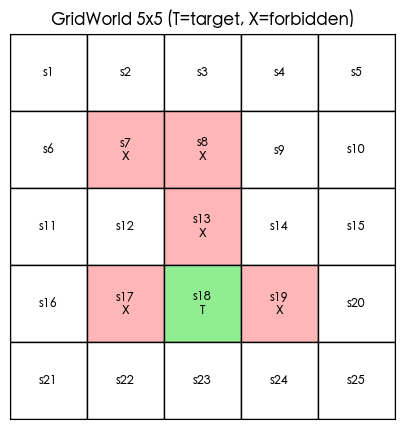

In [2]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_grid_layout(env, ax=ax, title='GridWorld 5x5 (T=target, X=forbidden)')
plt.savefig('figures/grid_layout.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. 单步动力学：调用 `step(s, a)`

MDP 的本质是 **(状态, 动作) → (下一状态, 奖励)**。从 s1=(0,0) 出发，逐个动作演示：


In [3]:
s = (0, 0)
print(f'当前状态 s = s{env.display_index(s)} (row={s[0]}, col={s[1]})\n')
print(f'{"动作 a":<8} {"s_next":<10} {"r(s,a)":<8} {"done"}')
print('-' * 36)
for a in env.actions:
    s_next, r, done = env.step(s, a)
    print(f'{a:<8} s{env.display_index(s_next):<9} {r:+.1f}     {done}')

当前状态 s = s1 (row=0, col=0)

动作 a     s_next     r(s,a)   done
------------------------------------
up       s1         -1.0     False
down     s6         +0.0     False
left     s1         -1.0     False
right    s2         +0.0     False
stay     s1         +0.0     False


**观察**：
- 在 s1 取 `up` 或 `left` 都撞墙，得 r=-1，状态不变
- 取 `down` 进入 s6，r=0
- 取 `right` 进入 s2，r=0
- 取 `stay` 留在 s1，r=0

## 4. 轨迹采样与折扣回报

**做法**：先调用 `value_iteration()` 计算最优策略 π*（L4 内容预演），用 π* 采轨迹。
这样得到的轨迹应当**完全绕开 forbidden 区**，且只在最后一步获得 r=+1。

In [4]:
# 手工策略：用 VI 算最优策略作为对照（绕开 forbidden）
V_star, optimal_policy, _ = env.value_iteration()

traj = rollout(env, optimal_policy, s0=(0, 0), max_steps=30)
print(f'轨迹长度 T = {len(traj)}\n')
print(f'{"t":<3} {"s":<5} {"a":<6} {"r":<6} {"s_next"}')
print('-' * 28)
for t, (s, a, r, s_next) in enumerate(traj):
    print(f'{t:<3} s{env.display_index(s):<4} {a:<6} {r:+.1f}   s{env.display_index(s_next)}')
G0 = discounted_return(traj, env.cfg.gamma)
print(f'\n折扣回报 G_0 = {G0:.4f}  (γ={env.cfg.gamma})')
print(f'理论值 γ^(T-1) = {env.cfg.gamma**(len(traj)-1):.4f}  (最优策略全程绕开 forbidden, 仅末步有 r=1)')

轨迹长度 T = 7

t   s     a      r      s_next
----------------------------
0   s1    down   +0.0   s6
1   s6    down   +0.0   s11
2   s11   down   +0.0   s16
3   s16   down   +0.0   s21
4   s21   right  +0.0   s22
5   s22   right  +0.0   s23
6   s23   up     +1.0   s18

折扣回报 G_0 = 0.5314  (γ=0.9)
理论值 γ^(T-1) = 0.5314  (最优策略全程绕开 forbidden, 仅末步有 r=1)


**教学诊断**：手工策略经过 T 步到达目标 → $G_0=\gamma^{T-1}$（最后一步得 r=1，前面都是 r=0）。

## 5. 轨迹可视化

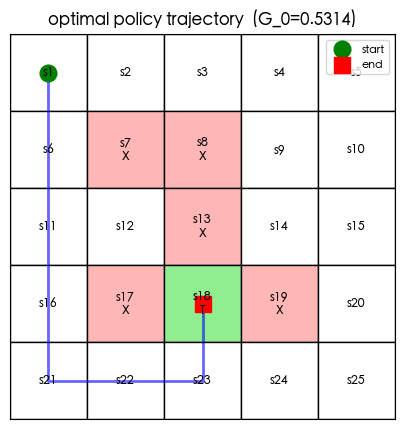

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_trajectory(env, traj, ax=ax, title=f'optimal policy trajectory  (G_0={G0:.4f})')
plt.savefig('figures/good_trajectory.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. 随机策略基线

每个状态独立等概率采一个固定动作（确定性的随机策略），跑 100 episode 看平均回报。

In [6]:
rng = np.random.default_rng(42)
returns = []
for _ in range(100):
    rp = random_policy(env, rng)
    tr = rollout(env, rp, s0=(0, 0), max_steps=50)
    returns.append(discounted_return(tr, env.cfg.gamma))

print(f'随机策略 (100 episodes):')
print(f'  mean G_0 = {np.mean(returns):+.4f}')
print(f'  std      = {np.std(returns):.4f}')
print(f'  min      = {np.min(returns):+.4f}')
print(f'  max      = {np.max(returns):+.4f}')
print(f'\n手工好策略 G_0 = {G0:+.4f}  (远高于随机)')

随机策略 (100 episodes):
  mean G_0 = -5.4875
  std      = 4.7781
  min      = -9.9485
  max      = +0.0000

手工好策略 G_0 = +0.5314  (远高于随机)


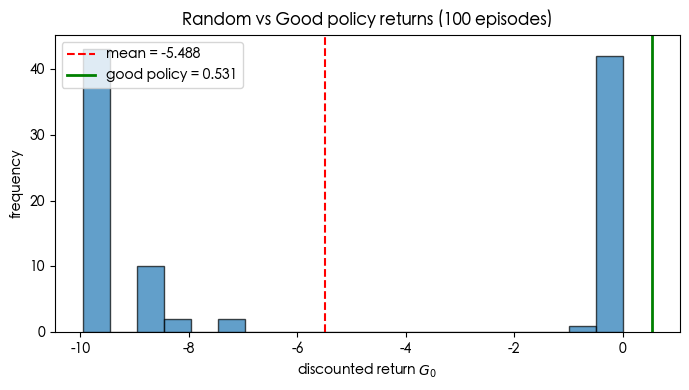

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(returns, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(np.mean(returns), color='red', linestyle='--', label=f'mean = {np.mean(returns):.3f}')
ax.axvline(G0, color='green', linestyle='-', linewidth=2, label=f'good policy = {G0:.3f}')
ax.set_xlabel('discounted return $G_0$')
ax.set_ylabel('frequency')
ax.set_title('Random vs Good policy returns (100 episodes)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/return_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. 课堂诊断小结

| 论断 | 数值验证 |
|---|---|
| MDP 五元组完整可计算 | $\|\mathcal{S}\|=25, \|\mathcal{A}\|=5, \gamma=0.9$ |
| 轨迹是 (s,a,r,s') 序列 | 上面打印了完整轨迹 |
| 折扣回报 = $\sum \gamma^t r_{t+1}$ | $G_0 \approx \gamma^{T-1}$（仅末步有奖励） |
| 策略影响回报 | 手工 $G_0 \gg$ 随机平均 |

## 思考题

1. 为什么 forbidden 区域不是终止状态？（提示：教学方便，让 agent 可以"穿过"禁区，看到 -1 的代价后能否学会绕路）
2. 如果把 `r_step` 从 0 改成 -0.1（每走一步罚一点），手工策略和随机策略的差距会变大还是变小？
3. γ=0 时智能体只关心当前奖励，γ=1 时考虑无穷远未来。本任务用 γ=0.9 隐含什么"耐心程度"？

**下一讲（L2）**：怎么不用 rollout 也能算出 v^π？答案是直接解贝尔曼方程 $\mathbf{v}^\pi = (I - \gamma P^\pi)^{-1}\mathbf{r}^\pi$。